<a href="https://colab.research.google.com/github/omegaguy9-cmd/terraform-reference-/blob/main/intern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("muted")

In [ ]:
try:
    df = pd.read_csv('/content/raw_battery_telemetry(39).csv')
    print(f"Dataset successfully loaded! Dimensions: {df.shape[0]} rows, {df.shape[1]} columns.")
except FileNotFoundError:
    print("Error: 'ev_trip_data.csv' not found. Please upload the CSV to Google Colab first.")

Dataset successfully loaded! Dimensions: 40001 rows, 19 columns.


In [ ]:
print(df.head(10));

   time_s  contractors_state  cumulative_odo_km  time_since_charge_s  \
0     0.0                  1            15000.0               3600.0   
1     0.1                  1            15000.0               3600.1   
2     0.2                  1            15000.0               3600.2   
3     0.3                  1            15000.0               3600.3   
4     0.4                  1            15000.0               3600.4   
5     0.5                  1            15000.0               3600.5   
6     0.6                  1            15000.0               3600.6   
7     0.7                  1            15000.0               3600.7   
8     0.8                  1            15000.0               3600.8   
9     0.9                  1            15000.0               3600.9   

   busbar_drop_mv  cell_current  cell_voltage  cell_soc  cell_temp  \
0             0.0           4.0          4.19       1.0  25.000000   
1             0.0           4.0          4.19       1.0  25.015688 

In [ ]:
print("=== Telemetry Dataset Summary ===")
display(df.describe().T)

=== Telemetry Dataset Summary ===


,count,mean,std,min,25%,50%,75%,max
time_s,40001.0,2000.000000,1154.743840,0.000000,1000.000000,2000.000000,3000.000000,4000.00000
contractors_state,40001.0,0.874978,0.330748,0.000000,1.000000,1.000000,1.000000,1.00000
cumulative_odo_km,40001.0,15000.139684,0.129839,15000.000000,15000.050000,15000.100000,15000.200000,15000.40000
time_since_charge_s,40001.0,5122.851179,878.876683,3600.000000,4360.000000,5120.000000,5880.000000,6740.00000
busbar_drop_mv,40001.0,41.905202,38.951742,0.000000,15.000000,30.000000,60.000000,120.00000
cell_current,40001.0,27.495919,25.351542,0.000000,10.172222,16.715432,40.000000,80.00000
cell_voltage,40001.0,3.580636,0.374303,2.697053,3.343267,3.600556,3.852015,4.20000
cell_soc,40001.0,0.553085,0.249681,0.202160,0.315617,0.539012,0.779794,1.00000
cell_temp,40001.0,55.098501,6.250750,25.000000,53.682505,56.336507,57.933641,65.00000
ambient_temp_c,40001.0,20.994613,13.188200,10.000000,10.000000,14.993680,24.988664,45.00000


In [ ]:
for lag in range(1, 6):
    df[f'cell_current_lag_{lag}'] = df['cell_current'].shift(lag)
    df[f'cell_voltage_lag_{lag}'] = df['cell_voltage'].shift(lag)

df['delta_cell_temp'] = df['cell_temp'].diff()

In [ ]:
feature_cols = [
    'contractors_state',
    'busbar_drop_mv',
    'cell_current',
    'cell_voltage',
    'ambient_temp_c',
    'hydrogen_ppm',
    'co_ppm',
    'humidity_pct',
    'coolant_flow_lpm',
    'coolant_outlet_c',
    'cooling_valve_pct',
    'coolant_inlet_c'
]
target_cols = ['cell_soc', 'cell_temp', 'strain_voltage_v', 'pack_pressure_kpa']

X = df[feature_cols]
y = df[target_cols]

scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y)

df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
df_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
contractors_state,40001.0,0.874978,0.330748,0.0,1.000000,1.000000,1.000000,1.0
busbar_drop_mv,40001.0,0.349210,0.324598,0.0,0.125000,0.250000,0.500000,1.0
cell_current,40001.0,0.343699,0.316894,0.0,0.127153,0.208943,0.500000,1.0
cell_voltage,40001.0,0.587900,0.249046,0.0,0.429965,0.601154,0.768465,1.0
ambient_temp_c,40001.0,0.314132,0.376806,0.0,0.000000,0.142677,0.428248,1.0
hydrogen_ppm,40001.0,0.404638,0.253479,0.0,0.245500,0.422434,0.528909,1.0
co_ppm,40001.0,0.404638,0.253479,0.0,0.245500,0.422434,0.528909,1.0
humidity_pct,40001.0,0.828447,0.133703,0.0,0.764307,0.843408,0.918661,1.0
coolant_flow_lpm,40001.0,0.524987,0.499382,0.0,0.000000,1.000000,1.000000,1.0
coolant_outlet_c,40001.0,0.469451,0.330851,0.0,0.181335,0.476044,0.632636,1.0


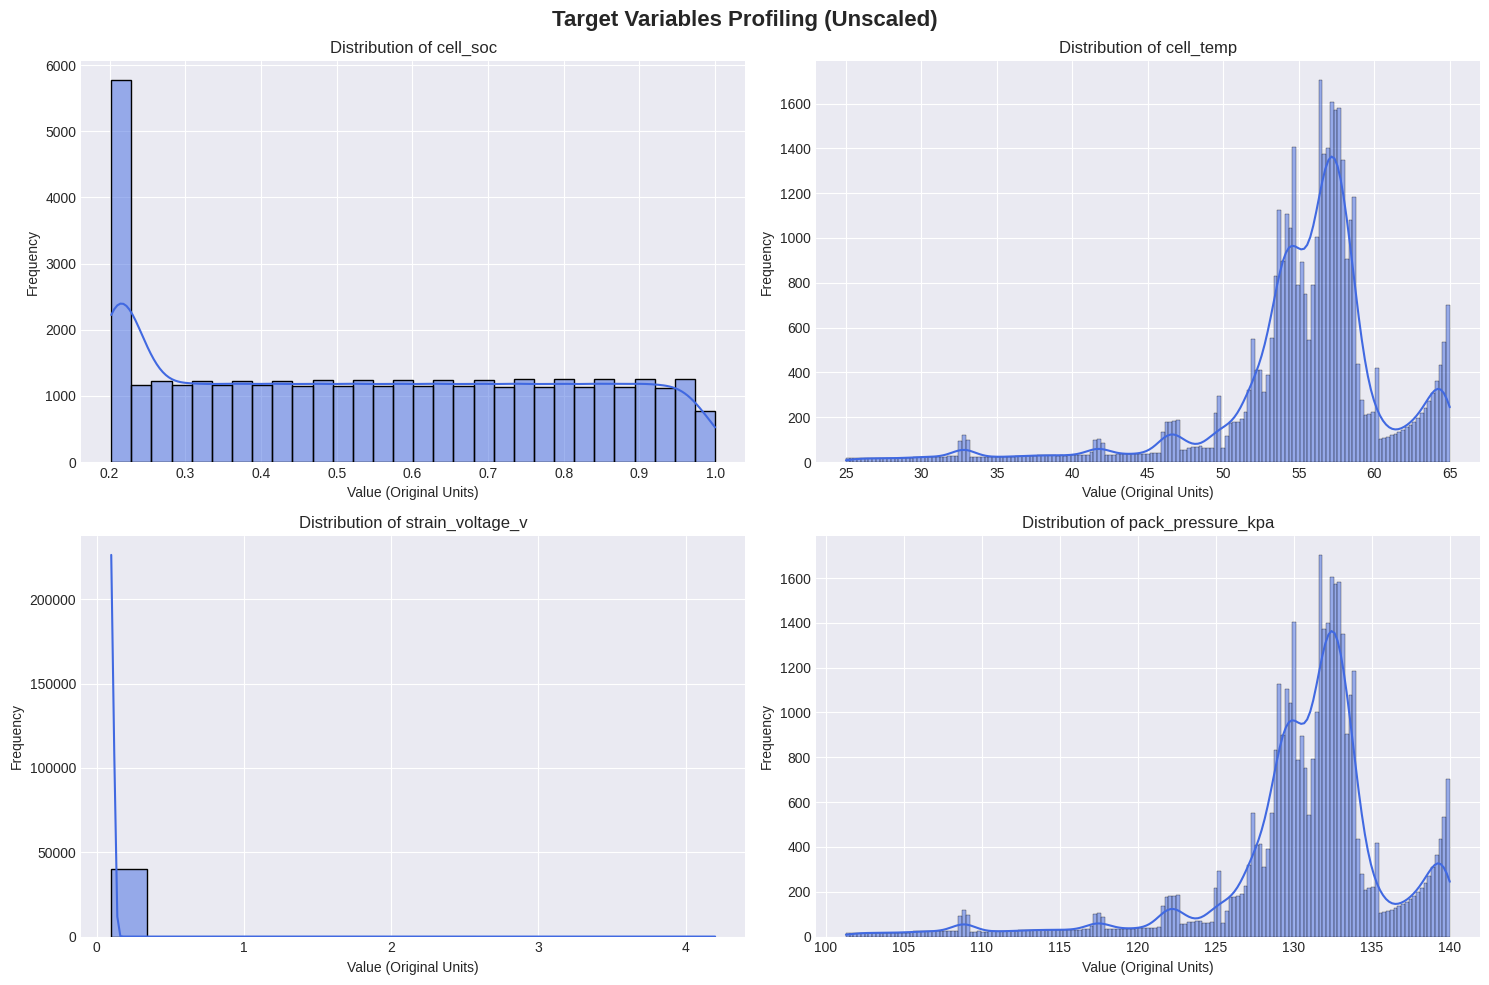

In [ ]:
targets = ['cell_soc', 'cell_temp', 'strain_voltage_v', 'pack_pressure_kpa']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(targets):
    sns.histplot(df[col], kde=True, ax=axes[i], color='royalblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('Value (Original Units)')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Target Variables Profiling (Unscaled)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

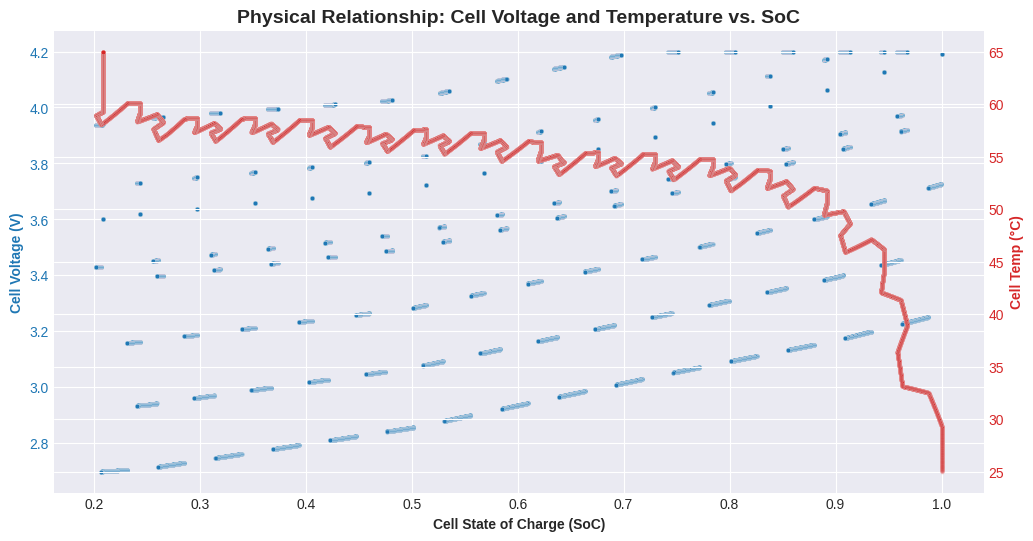

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Cell State of Charge (SoC)', fontweight='bold')
ax1.set_ylabel('Cell Voltage (V)', color=color, fontweight='bold')
sns.scatterplot(data=df, x='cell_soc', y='cell_voltage', ax=ax1, color=color, alpha=0.5, s=10)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Cell Temp (°C)', color=color, fontweight='bold')
sns.scatterplot(data=df, x='cell_soc', y='cell_temp', ax=ax2, color=color, alpha=0.1, s=10)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Physical Relationship: Cell Voltage and Temperature vs. SoC', fontsize=14, fontweight='bold')
plt.show()

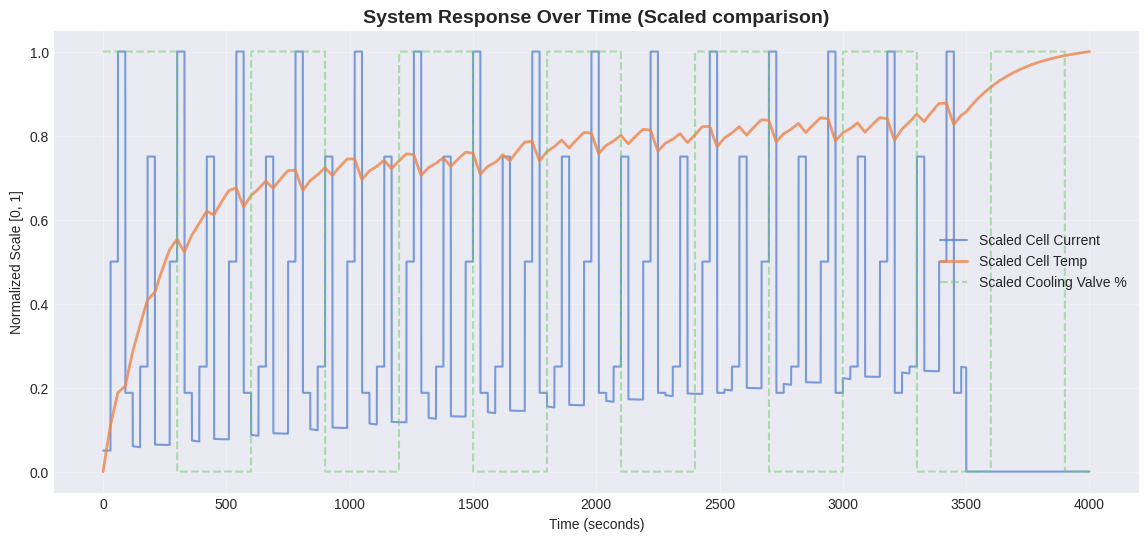

In [ ]:
df_scaled_all = pd.DataFrame(X_scaled, columns=feature_cols)
df_scaled_all[target_cols] = y_scaled
df_scaled_all['time_s'] = df['time_s'].values

plt.figure(figsize=(14, 6))
plt.plot(df_scaled_all['time_s'], df_scaled_all['cell_current'], label='Scaled Cell Current', alpha=0.7)
plt.plot(df_scaled_all['time_s'], df_scaled_all['cell_temp'], label='Scaled Cell Temp', alpha=0.8, linewidth=2)
plt.plot(df_scaled_all['time_s'], df_scaled_all['cooling_valve_pct'], label='Scaled Cooling Valve %', alpha=0.5, linestyle='--')

plt.title('System Response Over Time (Scaled comparison)', fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)')
plt.ylabel('Normalized Scale [0, 1]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

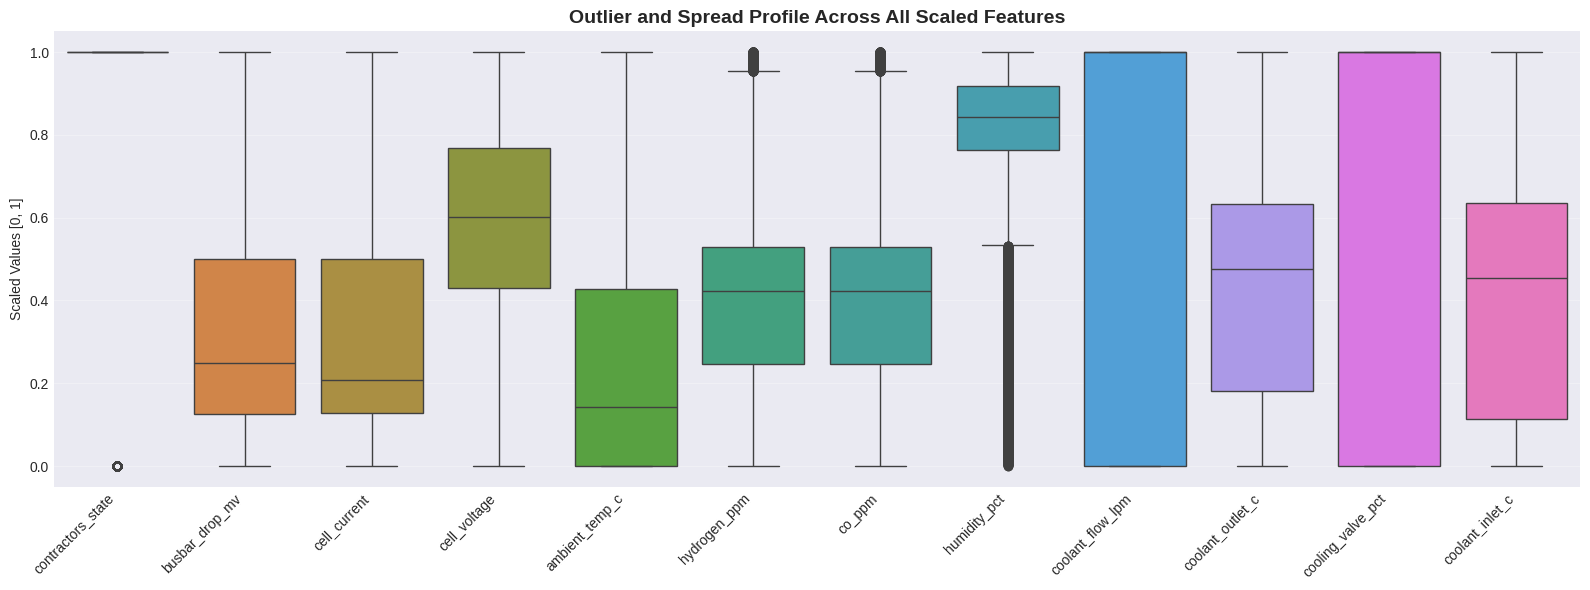

In [ ]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=pd.DataFrame(X_scaled, columns=feature_cols))
plt.xticks(rotation=45, ha='right')
plt.title('Outlier and Spread Profile Across All Scaled Features', fontsize=14, fontweight='bold')
plt.ylabel('Scaled Values [0, 1]')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

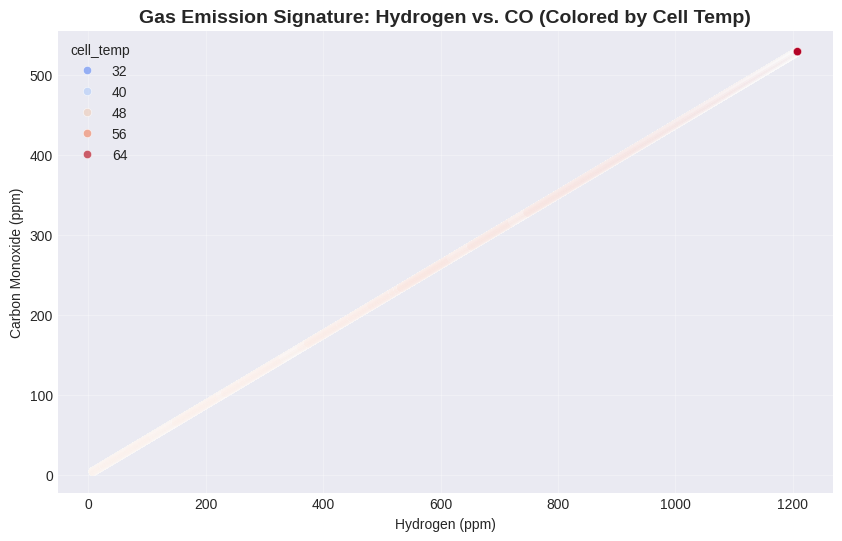

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='hydrogen_ppm', y='co_ppm', hue='cell_temp', palette='coolwarm', alpha=0.7)
plt.title('Gas Emission Signature: Hydrogen vs. CO (Colored by Cell Temp)', fontsize=14, fontweight='bold')
plt.xlabel('Hydrogen (ppm)')
plt.ylabel('Carbon Monoxide (ppm)')
plt.grid(True, alpha=0.3)
plt.show()

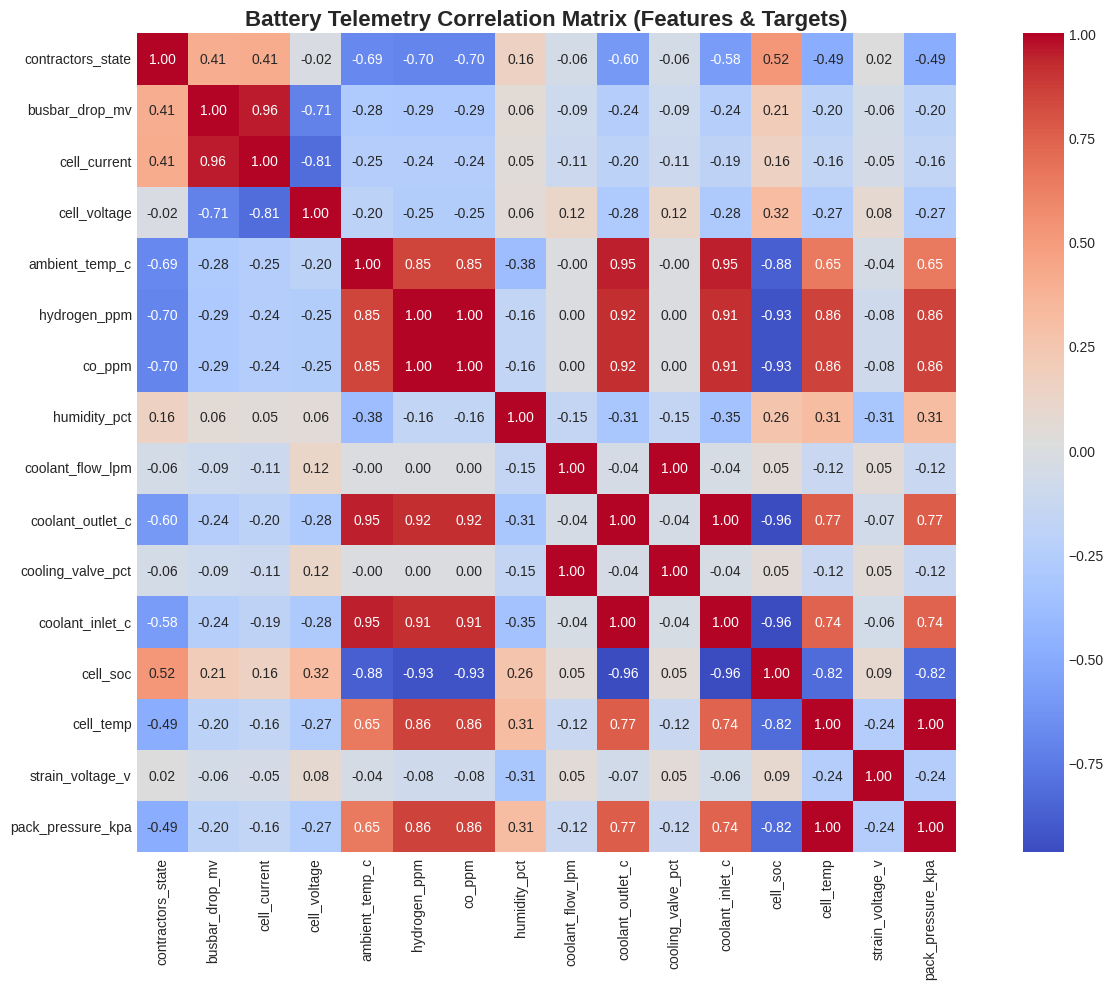

In [ ]:
full_corr_df = df[feature_cols + target_cols]

plt.figure(figsize=(14, 10))
corr_matrix = full_corr_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title('Battery Telemetry Correlation Matrix (Features & Targets)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

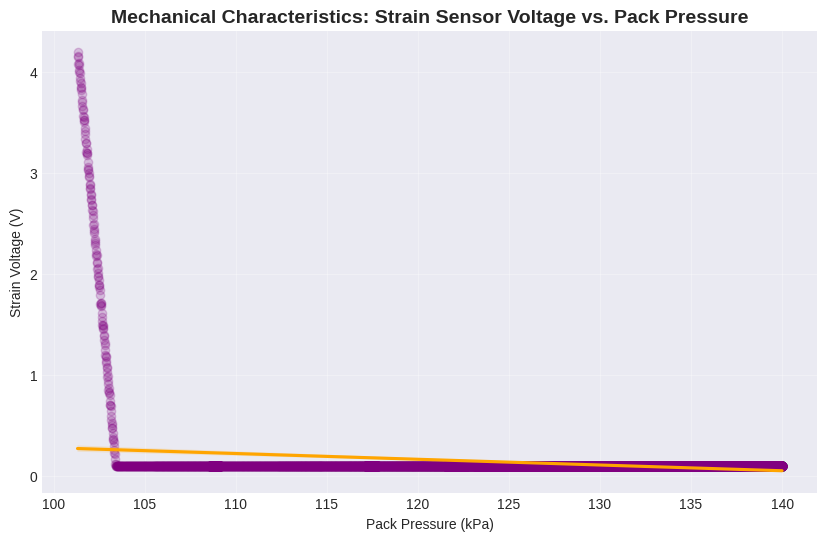

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='pack_pressure_kpa', y='strain_voltage_v',
            scatter_kws={'alpha':0.2, 'color':'purple'}, line_kws={'color':'orange'})
plt.title('Mechanical Characteristics: Strain Sensor Voltage vs. Pack Pressure', fontsize=14, fontweight='bold')
plt.xlabel('Pack Pressure (kPa)')
plt.ylabel('Strain Voltage (V)')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, shuffle=False
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 32000 samples
Testing set size: 8001 samples


In [ ]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01),
    "K-Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": MultiOutputRegressor(GradientBoostingRegressor(n_estimators=50, max_depth=5, random_state=42)),
    "XGBoost": MultiOutputRegressor(XGBRegressor(n_estimators=50, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)),
    "Neural Network (MLP)": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
import time

results = []

for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()

    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions, multioutput='uniform_average')

    results.append({
        "Model": name,
        "MAE (Scaled)": round(mae, 5),
        "R2 Score": round(r2, 5),
        "Training Time (s)": round(train_time, 2)
    })

df_results = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
display(df_results)

Training Linear Regression...
Training Ridge...
Training Lasso...
Training ElasticNet...
Training K-Neighbors...
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training Gradient Boosting...
Training XGBoost...
Training Neural Network (MLP)...


,Model,MAE (Scaled),R2 Score,Training Time (s)
2,Lasso,0.03258,-0.49496,0.05
10,Neural Network (MLP),0.06753,-3.30691,1.56
3,ElasticNet,0.03072,-4.76458,0.05
4,K-Neighbors,0.07224,-8.00312,0.14
7,Extra Trees,0.07940,-9.93118,1.00
9,XGBoost,0.07377,-11.19088,1.76
8,Gradient Boosting,0.07414,-11.45034,41.91
5,Decision Tree,0.07456,-11.61095,0.41
6,Random Forest,0.07680,-11.98074,8.59
1,Ridge,0.17383,-66.48236,0.01


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,Model,Architecture,MAE (Scaled),R2 Score,Training Time (s)
0,LSTM (Sequence Window),Deep Recurrent (Time-Aware),0.04250,0.10227,58.65
1,Neural Network (MLP),Static ML,0.09733,-6.82969,2.01
2,K-Neighbors,Static ML,0.08234,-8.22901,0.15
3,Extra Trees,Static ML,0.08821,-9.25051,0.99
4,Decision Tree,Static ML,0.08425,-10.76042,0.44
5,XGBoost,Static ML,0.08378,-11.12432,0.49
6,Gradient Boosting,Static ML,0.08442,-11.45931,39.17
7,Random Forest,Static ML,0.08581,-11.67199,7.21
8,Lasso,Static ML,0.06438,-12.93155,0.37
9,ElasticNet,Static ML,0.09136,-25.24015,0.13


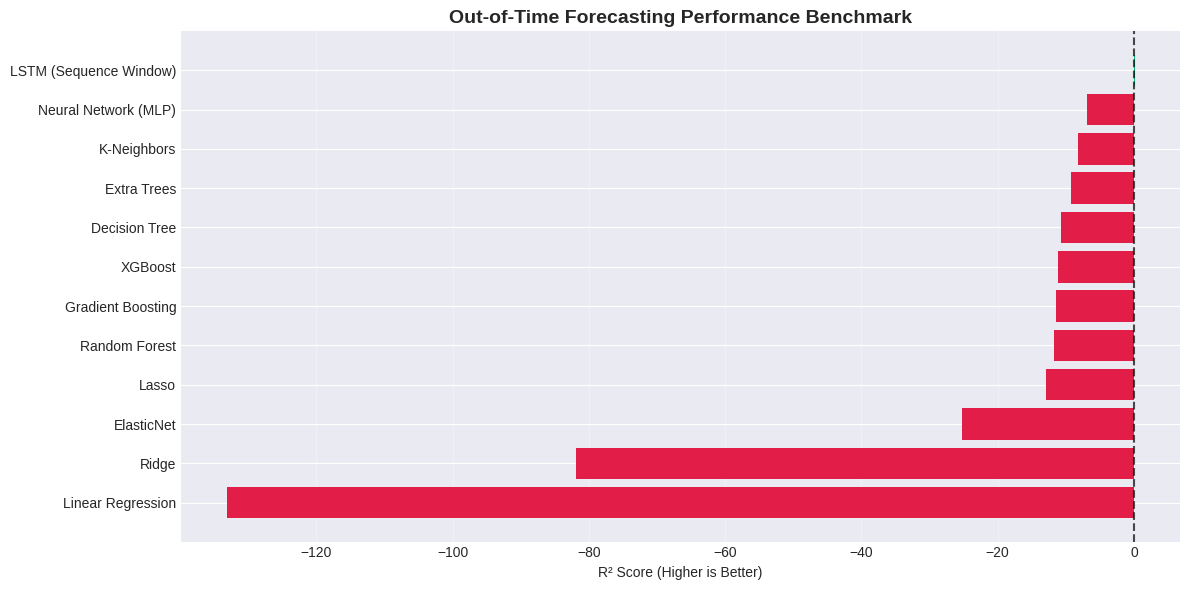

In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeRegressor
import tensorflow as tf
from xgboost import XGBRegressor

df_clean = df[feature_cols + target_cols].dropna().reset_index(drop=True)
split_idx = int(len(df_clean) * 0.8)

train_df = df_clean.iloc[:split_idx]
test_df = df_clean.iloc[split_idx:]

scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(train_df[feature_cols])
X_test_scaled = scaler_X.transform(test_df[feature_cols])

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(train_df[target_cols])
y_test_scaled = scaler_y.transform(test_df[target_cols])

LOOKBACK = 10

def create_sequences(X, y, time_steps=LOOKBACK):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:(i + time_steps)])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01),
    "K-Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": MultiOutputRegressor(GradientBoostingRegressor(n_estimators=50, max_depth=5, random_state=42)),
    "XGBoost": MultiOutputRegressor(XGBRegressor(n_estimators=50, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)),
    "Neural Network (MLP)": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

results = []

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_scaled, y_train_scaled)
    train_time = time.time() - start_time

    preds = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test_scaled, preds)
    r2 = r2_score(y_test_scaled, preds, multioutput="uniform_average")

    results.append({
        "Model": name,
        "Architecture": "Static ML",
        "MAE (Scaled)": round(mae, 5),
        "R2 Score": round(r2, 5),
        "Training Time (s)": round(train_time, 2),
    })

lstm_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(LOOKBACK, X_train_seq.shape[2])),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(y_train_seq.shape[1])
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="huber",
    metrics=["mae"],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)
]

start_time = time.time()
lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    verbose=0
)
lstm_train_time = time.time() - start_time

lstm_preds = lstm_model.predict(X_test_seq)
lstm_mae = mean_absolute_error(y_test_seq, lstm_preds)
lstm_r2 = r2_score(y_test_seq, lstm_preds, multioutput="uniform_average")

results.append({
    "Model": "LSTM (Sequence Window)",
    "Architecture": "Deep Recurrent (Time-Aware)",
    "MAE (Scaled)": round(lstm_mae, 5),
    "R2 Score": round(lstm_r2, 5),
    "Training Time (s)": round(lstm_train_time, 2),
})

df_results = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
display(df_results)

best_model_name = df_results.iloc[0]["Model"]
colors = ["#10b981" if m == best_model_name else "#e11d48" for m in df_results["Model"]]

plt.figure(figsize=(12, 6))
plt.barh(df_results["Model"], df_results["R2 Score"], color=colors)
plt.axvline(0, color="black", linestyle="--", alpha=0.7)
plt.title("Out-of-Time Forecasting Performance Benchmark", fontsize=14, fontweight="bold")
plt.xlabel("R² Score (Higher is Better)")
plt.grid(axis="x", alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
import os
import zipfile
from google.colab import files

lstm_model.save("best_battery_lstm_model.keras")

import pickle

with open("scaler_X.pkl", "wb") as f:
  pickle.dump(scaler_X, f)

with open("scaler_y.pkl", "wb") as f:
  pickle.dump(scaler_y, f)

requirements = """fastapi
uvicorn
tensorflow
scikit-learn
pandas
numpy
pydantic
"""
with open("requirements.txt", "w") as f:
  f.write(requirements)

export_files = [
    "best_battery_lstm_model.keras",
    "scaler_X.pkl",
    "scaler_y.pkl",
    "requirements.txt",
]
with zipfile.ZipFile("bms_digital_twin_assets.zip", "w") as zipf:
  for file in export_files:
    if os.path.exists(file):
      zipf.write(file)

files.download("bms_digital_twin_assets.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>